In [ ]:
"""
Install required packages for Quranic NER project.

This cell installs all dependencies needed for BiLSTM and CRF models.
"""
import subprocess
import sys

# List of required packages
required_packages = [
    'numpy',
    'pandas',
    'tensorflow',
    'scikit-learn',
    'seaborn',
    'matplotlib',
    'nltk',
    'keras',
    'sklearn_crfsuite',
    'highlight_text',
    'scipy'
]

print("🔧 Installing required packages...")
failed_packages = []

for package in required_packages:
    try:
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package],
            capture_output=True,
            timeout=300
        )
        if result.returncode != 0:
            failed_packages.append(package)
            print(f"⚠️  Warning: Failed to install {package}")
    except subprocess.TimeoutExpired:
        failed_packages.append(package)
        print(f"⚠️  Warning: Timeout installing {package}")
    except Exception as e:
        failed_packages.append(package)
        print(f"⚠️  Warning: Error installing {package}: {str(e)}")

if failed_packages:
    print(f"\n⚠️  Failed packages: {', '.join(failed_packages)}")
else:
    print("\n✅ All packages installed successfully!")

Installing required packages...
✓ All packages installed successfully!


In [ ]:
"""
Import all required libraries for NER models.

Libraries are organized into categories:
- Data manipulation: numpy, pandas
- Machine learning: scikit-learn, tensorflow, keras
- NLP: nltk, sklearn_crfsuite
- Visualization: matplotlib, seaborn, highlight_text
"""

# ============================================================
# SECTION 1: IMPORT LIBRARIES
# ============================================================

# Data processing and numerical computing
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Deep learning frameworks
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, LSTM, Embedding, Dense, 
                                     TimeDistributed, SpatialDropout1D, 
                                     Bidirectional)
from keras import backend as K

# Machine learning models
import sklearn_crfsuite
from sklearn_crfsuite import scorers, metrics
from sklearn.metrics import precision_recall_fscore_support

# Natural language processing
import nltk

# Visualization and plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from highlight_text import HighlightText, ax_text, fig_text

# Utilities
from itertools import chain
import random
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Download required NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    print("✅ NLTK data downloaded successfully")
except Exception as e:
    print(f"⚠️  Warning: Could not download NLTK data: {str(e)}")

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# ============================================================
# SECTION 2: LOAD & PREPROCESS DATASET (BiLSTM)
# ============================================================
"""
Load and explore the Quranic NER dataset.

The dataset contains Quranic text with Named Entity Recognition labels.
"""

# Load dataset with error handling
dataset_path = 'data/quranic_ner_dataset.xlsx'

try:
    dataset = pd.read_excel(dataset_path)
    print(f"✅ Dataset loaded successfully from {dataset_path}")
    print(f"Dataset shape: {dataset.shape}")
    print(f"\nFirst few rows:")
    print(dataset.head())
except FileNotFoundError:
    print(f"❌ Error: Dataset file not found at {dataset_path}")
    raise
except Exception as e:
    print(f"❌ Error loading dataset: {str(e)}")
    raise

       juz  no_ayat  word_list pos_list level_2 level_2.1 joint_tag
0        1        1     Dengan       SC       O         O       O+O
1        1        1   menyebut       VB       O         O       O+O
2        1        1       nama       NN       O         O       O+O
3        1        1      Allah      NNP       O         O       O+O
4        1        1       Yang      NNP       O         O       O+O
...    ...      ...        ...      ...     ...       ...       ...
36747    6      165       Maha      NNP       O         O       O+O
36748    6      165  Pengampun      NNP       O         O       O+O
36749    6      165       lagi       RB       O         O       O+O
36750    6      165       Maha      NNP       O         O       O+O
36751    6      165  Penyayang      NNP       O         O       O+O

[36752 rows x 7 columns]


In [ ]:
"""
Clean and preprocess the dataset.

- Drop unnecessary columns
- Rename columns to standardized names
"""

try:
    # Drop unused columns
    columns_to_drop = ['juz', 'no_ayat', 'pos_list', 'level_2.1', 'joint_tag']
    dataset = dataset.drop(columns_to_drop, axis=1)
    
    # Rename columns to more standard names
    column_mapping = {
        'word_list': 'words',
        'level_2': 'tags'
    }
    dataset = dataset.rename(columns=column_mapping)
    
    print("✅ Data cleaning completed")
    print(f"Dataset columns: {list(dataset.columns)}")
    print(f"\nDataset preview:")
    print(dataset.head(10))
    
except KeyError as e:
    print(f"❌ Error: Column not found: {str(e)}")
    print(f"Available columns: {list(dataset.columns)}")
    raise
except Exception as e:
    print(f"❌ Error during data cleaning: {str(e)}")
    raise

           words tags
0         Dengan    O
1       menyebut    O
2           nama    O
3          Allah    O
4           Yang    O
...          ...  ...
36747       Maha    O
36748  Pengampun    O
36749       lagi    O
36750       Maha    O
36751  Penyayang    O

[36752 rows x 2 columns]


In [ ]:
"""
Extract unique words and tags from dataset.

Creates vocabulary for encoding:
- unique_words: List of all unique words in the dataset
- unique_tags: List of all unique NER tags in the dataset
"""

try:
    # Extract unique words and tags
    unique_words = list(set(dataset['words'].values))
    num_unique_words = len(unique_words)
    
    unique_tags = list(set(dataset['tags'].values))
    num_unique_tags = len(unique_tags)
    
    print("✅ Vocabulary extraction completed")
    print(f"Number of unique words: {num_unique_words}")
    print(f"Number of unique tags: {num_unique_tags}")
    print(f"\nSample words: {unique_words[:10]}")
    print(f"All tags: {unique_tags}")
    
except Exception as e:
    print(f"❌ Error extracting vocabulary: {str(e)}")
    raise

In [ ]:
print(words[:10])
print(tags)

['sehelai', 'berkhidmat', 'buruk-buruk', 'aman', 'amal-amal', 'bertakwa', 'nafkahkanlah', 'cabut', 'kepada-Nya-lah', 'disembah']
['O', 'B-PER', 'I-PER']


In [ ]:
"""
Create word and tag index mappings.

Mappings:
- word_to_index: Maps words to numerical indices
- index_to_word: Reverse mapping of word_to_index
- tag_to_index: Maps tags to numerical indices
- index_to_tag: Reverse mapping of tag_to_index

Special tokens:
- PAD (0): Padding token for sequence alignment
- UNK (1): Unknown token for out-of-vocabulary words
"""

try:
    # Create word-to-index mapping
    # Reserve 0 for PAD and 1 for UNK
    word_to_index = {word: idx + 2 for idx, word in enumerate(unique_words)}
    word_to_index['UNK'] = 1  # Unknown word token
    word_to_index['PAD'] = 0  # Padding token
    
    # Create reverse mapping
    index_to_word = {idx: word for word, idx in word_to_index.items()}
    
    # Create tag-to-index mapping
    # Reserve 0 for PAD
    tag_to_index = {tag: idx + 1 for idx, tag in enumerate(unique_tags)}
    tag_to_index['PAD'] = 0  # Padding token
    
    # Create reverse mapping
    index_to_tag = {idx: tag for tag, idx in tag_to_index.items()}
    
    print("✅ Index mappings created successfully")
    print(f"\nWord vocabulary size: {len(word_to_index)}")
    print(f"Tag vocabulary size: {len(tag_to_index)}")
    print(f"\nSample word mappings: {dict(list(word_to_index.items())[:5])}")
    print(f"Tag mappings: {tag_to_index}")
    
except Exception as e:
    print(f"❌ Error creating index mappings: {str(e)}")
    raise

In [ ]:
"""
Split dataset into training and testing sets.

Parameters:
- test_size: 0.2 (20% for testing, 80% for training)
- random_state: 42 (for reproducibility)
"""

try:
    training_data, testing_data = train_test_split(
        dataset,
        test_size=0.2,
        random_state=42
    )
    
    print("✅ Dataset split completed")
    print(f"Training set size: {len(training_data)} samples")
    print(f"Testing set size: {len(testing_data)} samples")
    print(f"Train/Test ratio: {len(training_data)/len(testing_data):.1f}:1")
    
except Exception as e:
    print(f"❌ Error splitting dataset: {str(e)}")
    raise

In [ ]:
print(len(train))
print(len(test))

29401
7351


In [ ]:
"""
Convert words and tags to input/output sequences for BiLSTM model.

This function:
1. Extracts words and tags from dataframe
2. Converts them to numerical indices
3. Pads sequences to fixed length (50 tokens)
4. Converts tags to one-hot encoded format

Args:
    data (pd.DataFrame): DataFrame containing 'words' and 'tags' columns

Returns:
    tuple: (X, y) where:
        - X: numpy array of shape (num_sequences, 50) - padded word indices
        - y: numpy array of shape (num_sequences, 50, num_tags+1) - one-hot encoded tags
"""

def get_input_output(data):
    try:
        # Extract words and tags from dataframe
        if 'words' not in data.columns or 'tags' not in data.columns:
            raise ValueError("DataFrame must contain 'words' and 'tags' columns")
        
        words_list = data['words'].values.tolist()
        tags_list = data['tags'].values.tolist()
        
        if not words_list or not tags_list:
            raise ValueError("Words and tags lists are empty")
        
        # Convert words to indices (using unknown token for OOV words)
        sequences_word_idx = [
            [word_to_index.get(w, word_to_index['UNK']) for w in words_list[i:i+50]]
            for i in range(0, len(words_list), 50)
        ]
        
        # Pad word sequences to length 50
        sequences_word_padded = pad_sequences(
            maxlen=50,
            sequences=sequences_word_idx,
            padding="post",
            value=word_to_index['PAD']
        )
        
        # Convert tags to indices
        sequences_tag_idx = [
            [tag_to_index.get(t, tag_to_index['PAD']) for t in tags_list[i:i+50]]
            for i in range(0, len(tags_list), 50)
        ]
        
        # Pad tag sequences to length 50
        sequences_tag_padded = pad_sequences(
            maxlen=50,
            sequences=sequences_tag_idx,
            padding="post",
            value=tag_to_index['PAD']
        )
        
        # Convert tags to one-hot encoding
        sequences_tag_onehot = [
            to_categorical(seq, num_classes=num_unique_tags+1)
            for seq in sequences_tag_padded
        ]
        
        return sequences_word_padded, np.array(sequences_tag_onehot)
        
    except KeyError as e:
        print(f"❌ Error: Column not found: {str(e)}")
        raise
    except Exception as e:
        print(f"❌ Error in get_input_output: {str(e)}")
        raise

In [ ]:
"""
Create BiLSTM Neural Network architecture for NER.

Architecture:
    Input (50 tokens)
        ↓
    Embedding (50-dim embeddings for each word)
        ↓
    SpatialDropout1D (20% dropout for regularization)
        ↓
    Bidirectional LSTM (100 units, reads sequence forward and backward)
        ↓
    TimeDistributed Dense (softmax activation for each token)
        ↓
    Output (NER tags for each token)

Model details:
- Input: Sequences of word indices (batch_size, 50)
- Embedding: Maps indices to 50-dimensional vectors
- BiLSTM: Processes sequences bidirectionally with 100 hidden units
- Dropout: 10% recurrent dropout, 20% spatial dropout
- Output: Softmax probabilities for each NER tag per token
"""

try:
    # Define model architecture
    input_layer = Input(shape=(50,), name='input_words')
    
    # Embedding layer: converts word indices to dense vectors
    embedding_layer = Embedding(
        input_dim=num_unique_words+2,  # +2 for PAD and UNK tokens
        output_dim=50,                 # embedding dimension
        input_length=50,
        name='embedding'
    )(input_layer)
    
    # Spatial dropout: drops entire feature maps randomly
    dropout_layer = SpatialDropout1D(rate=0.2, name='spatial_dropout')(embedding_layer)
    
    # Bidirectional LSTM: processes sequence forward and backward
    bilstm_layer = Bidirectional(
        LSTM(units=100, return_sequences=True, recurrent_dropout=0.1),
        name='bilstm'
    )(dropout_layer)
    
    # TimeDistributed Dense: applies dense layer to each timestep
    output_layer = TimeDistributed(
        Dense(num_unique_tags+1, activation='softmax'),
        name='output_tags'
    )(bilstm_layer)
    
    # Create model
    bilstm_model = Model(input_layer, output_layer, name='BiLSTM_NER')
    
    print("✅ BiLSTM model created successfully")
    print(f"\nModel Summary:")
    bilstm_model.summary()
    
except Exception as e:
    print(f"❌ Error creating BiLSTM model: {str(e)}")
    raise

In [ ]:
"""
Define custom metrics for model evaluation.

Custom metrics:
- recall_m: Proportion of actual positives correctly identified
- precision_m: Proportion of positive predictions that are correct
- f1_m: Harmonic mean of precision and recall
"""

def recall_metric(y_true, y_pred):
    """
    Calculate recall (sensitivity/true positive rate).
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted probabilities
    
    Returns:
        Recall score (0 to 1)
    """
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_metric(y_true, y_pred):
    """
    Calculate precision (positive predictive value).
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted probabilities
    
    Returns:
        Precision score (0 to 1)
    """
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_metric(y_true, y_pred):
    """
    Calculate F1 score (harmonic mean of precision and recall).
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted probabilities
    
    Returns:
        F1 score (0 to 1)
    """
    precision = precision_metric(y_true, y_pred)
    recall = recall_metric(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

# Compile model with Adam optimizer and categorical crossentropy loss
try:
    bilstm_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',  # Multiclass classification
        metrics=['acc', f1_metric, precision_metric, recall_metric]
    )
    
    print("✅ Model compiled successfully")
    print("Optimizer: Adam")
    print("Loss: Categorical Crossentropy")
    print("Metrics: Accuracy, F1-Score, Precision, Recall")
    
except Exception as e:
    print(f"❌ Error compiling model: {str(e)}")
    raise

In [ ]:
"""
Prepare training and testing data for BiLSTM model.

Converts raw data to numerical sequences and one-hot encoded labels.
"""

try:
    print("🔄 Preparing training data...")
    x_train_bilstm, y_train_bilstm = get_input_output(training_data)
    print(f"✅ Training data shape: X={x_train_bilstm.shape}, y={y_train_bilstm.shape}")
    
    print("\n🔄 Preparing testing data...")
    x_test_bilstm, y_test_bilstm = get_input_output(testing_data)
    print(f"✅ Testing data shape: X={x_test_bilstm.shape}, y={y_test_bilstm.shape}")
    
    print(f"\nData preparation summary:")
    print(f"- Training samples: {len(x_train_bilstm)}")
    print(f"- Testing samples: {len(x_test_bilstm)}")
    print(f"- Sequence length: 50 tokens")
    print(f"- Output classes: {num_unique_tags + 1} (including PAD)")
    
except Exception as e:
    print(f"❌ Error preparing data: {str(e)}")
    raise

In [ ]:
# ============================================================
# SECTION 3: TRAINING & EVALUATION FUNCTIONS (BiLSTM)
# ============================================================

def evaluate_bilstm_model(x_train, y_train, x_test, y_test, epochs=25):
    """
    Train and evaluate the BiLSTM model.
    
    Args:
        x_train (np.ndarray): Training feature sequences (batch_size, 50)
        y_train (np.ndarray): Training labels (batch_size, 50, num_tags+1)
        x_test (np.ndarray): Testing feature sequences
        y_test (np.ndarray): Testing labels
        epochs (int): Number of training epochs (default: 25)
    
    Returns:
        pd.DataFrame: Evaluation metrics (Loss, Accuracy, F1, Precision, Recall)
    
    Raises:
        ValueError: If input arrays have invalid shapes
        Exception: If training or evaluation fails
    """
    try:
        # Validate input shapes
        if len(x_train) == 0 or len(x_test) == 0:
            raise ValueError("Training or testing data is empty")
        
        print(f"\n{'='*70}")
        print(f"🚀 Training BiLSTM Model for {epochs} epochs...")
        print(f"{'='*70}\n")
        
        # Train model
        history = bilstm_model.fit(
            x_train, y_train,
            batch_size=128,
            epochs=epochs,
            validation_split=0.1,
            verbose=1
        )
        
        print(f"\n{'='*70}")
        print("📊 Evaluating model on test set...")
        print(f"{'='*70}\n")
        
        # Evaluate on test set
        evaluation_results = bilstm_model.evaluate(x_test, y_test, batch_size=128)
        
        # Create results dataframe
        metrics_data = [
            ['Loss', round(evaluation_results[0], 4)],
            ['Accuracy', round(evaluation_results[1], 4)],
            ['F1 Score', round(evaluation_results[2], 4)],
            ['Precision', round(evaluation_results[3], 4)],
            ['Recall', round(evaluation_results[4], 4)]
        ]
        results_dataframe = pd.DataFrame(
            metrics_data,
            columns=['Metric', 'Score']
        )
        
        # Plot results
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x='Metric', y='Score', data=results_dataframe, palette='viridis')
        ax.bar_label(ax.containers[0], fmt='%.4f')
        ax.set_title(f'BiLSTM Model Evaluation Results (Epochs: {epochs})',
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Metric', fontsize=12)
        ax.set_ylabel('Score', fontsize=12)
        ax.set_ylim([0, 1.0])
        plt.tight_layout()
        plt.show()
        plt.close()
        
        print(f"\n{'='*70}")
        print("✅ Model evaluation completed successfully!")
        print(f"{'='*70}\n")
        
        return results_dataframe
        
    except ValueError as e:
        print(f"❌ Validation Error: {str(e)}")
        raise
    except Exception as e:
        print(f"❌ Error during model evaluation: {str(e)}")
        raise

Epoch 1/25
5/5 [==============================] - 11s 942ms/step - loss: 0.5433 - acc: 0.7818 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00 - val_loss: 0.4548 - val_acc: 0.9003 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 2/25
5/5 [==============================] - 5s 1s/step - loss: 0.3071 - acc: 0.9142 - f1_m: 0.6533 - precision_m: 0.7324 - recall_m: 0.6218 - val_loss: 0.2915 - val_acc: 0.9003 - val_f1_m: 0.9003 - val_precision_m: 0.9003 - val_recall_m: 0.9003
Epoch 3/25
5/5 [==============================] - 4s 770ms/step - loss: 0.2165 - acc: 0.9142 - f1_m: 0.9119 - precision_m: 0.9119 - recall_m: 0.9119 - val_loss: 0.1976 - val_acc: 0.9003 - val_f1_m: 0.9003 - val_precision_m: 0.9003 - val_recall_m: 0.9003
Epoch 4/25
5/5 [==============================] - 4s 744ms/step - loss: 0.1858 - acc: 0.9142 - f1_m: 0.9163 - precision_m: 0.9163 - recall_m: 0.9163 - val_loss: 0.1946 - val_acc: 0.9003 - val_f1_m: 0.9003 - val_preci

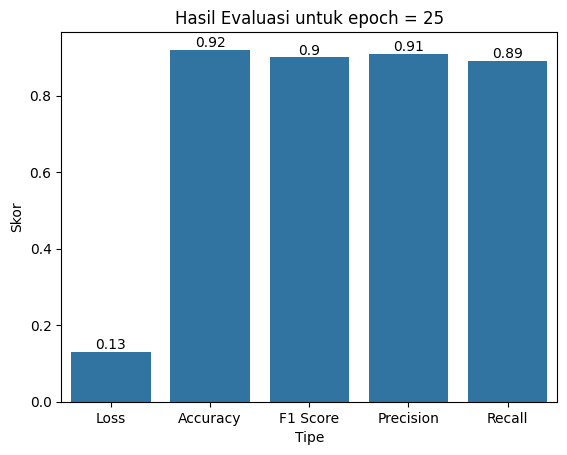

<Figure size 640x480 with 0 Axes>

In [ ]:
"""
Train and evaluate BiLSTM model for 25 epochs.
"""

try:
    bilstm_results_df = evaluate_bilstm_model(
        x_train_bilstm, y_train_bilstm,
        x_test_bilstm, y_test_bilstm,
        epochs=25
    )
    print("Results Summary:")
    print(bilstm_results_df.to_string(index=False))
    
except Exception as e:
    print(f"❌ Error training BiLSTM model: {str(e)}")

In [ ]:
"""
Make NER predictions on new Quranic text sentences.

This function takes a sentence as input and returns predicted NER tags
for each word in the sentence.
"""

def predict_ner_tags(input_sentence):
    """
    Predict NER tags for a given sentence using the trained BiLSTM model.
    
    Args:
        input_sentence (str): Input sentence in Quranic text
    
    Returns:
        list: List of tuples (word, predicted_tag) for each word
    
    Raises:
        ValueError: If input sentence is empty or invalid
        Exception: If prediction fails
    """
    try:
        if not isinstance(input_sentence, str):
            raise ValueError("Input must be a string")
        
        if len(input_sentence.strip()) == 0:
            raise ValueError("Input sentence cannot be empty")
        
        # Split sentence into words
        words_list = input_sentence.split()
        
        if len(words_list) > 50:
            print(f"⚠️  Warning: Sentence has {len(words_list)} words (max: 50)")
            print("    Truncating to first 50 words...")
            words_list = words_list[:50]
        
        # Convert words to indices (use UNK for unknown words)
        word_indices = [
            word_to_index.get(word, word_to_index['UNK'])
            for word in words_list
        ]
        
        # Pad to length 50
        sequences_padded = pad_sequences(
            maxlen=50,
            sequences=[word_indices],
            padding="post",
            value=word_to_index['PAD']
        )
        
        # Make predictions
        predictions = bilstm_model.predict(sequences_padded, verbose=0)
        predicted_indices = np.argmax(predictions, axis=-1)
        
        # Convert indices back to tags
        predicted_tags = [
            (words_list[idx], index_to_tag[predicted_indices[0][idx]])
            for idx in range(len(words_list))
        ]
        
        return predicted_tags
        
    except ValueError as e:
        print(f"❌ Validation Error: {str(e)}")
        raise
    except KeyError as e:
        print(f"❌ Error: Index mapping not found: {str(e)}")
        raise
    except Exception as e:
        print(f"❌ Error during prediction: {str(e)}")
        raise

In [ ]:
"""
Example: Make NER predictions on Quranic text.
"""

try:
    # Example Quranic sentence
    example_sentence = "(yaitu) jalan orang-orang yang telah Engkau beri nikmat kepadanya; bukan (jalan) mereka yang dimurkai, dan bukan (pula jalan) mereka yang sesat."
    
    print("📝 Input Sentence:")
    print(f"   {example_sentence}\n")
    
    print("🔍 Predictions:")
    print(f"{'Word':<20} {'Predicted Tag':<20}")
    print("-" * 40)
    
    predictions = predict_ner_tags(example_sentence)
    for word, tag in predictions:
        print(f"{word:<20} {tag:<20}")
    
except Exception as e:
    print(f"❌ Error making predictions: {str(e)}")

1/1 [==============================] - 1s 510ms/step
('(yaitu)', 'O')
('jalan', 'O')
('orang-orang', 'B-PER')
('yang', 'I-PER')
('telah', 'O')
('Engkau', 'O')
('beri', 'O')
('nikmat', 'O')
('kepadanya;', 'O')
('bukan', 'O')
('(jalan)', 'O')
('mereka', 'O')
('yang', 'I-PER')
('dimurkai,', 'O')
('dan', 'O')
('bukan', 'O')
('(pula', 'O')
('jalan)', 'O')
('mereka', 'O')
('yang', 'I-PER')
('sesat.', 'O')


Untuk CRF

In [ ]:
# ============================================================
# SECTION 4: CONDITIONAL RANDOM FIELD (CRF) MODEL
# ============================================================
# Additional setup for CRF visualization
plt.style.use('ggplot')

In [ ]:
"""
Load and preprocess dataset for CRF model.

CRF model uses similar data but with different preprocessing
to extract explicit features instead of learning them automatically.
"""

try:
    dataset_path = 'data/quranic_ner_dataset.xlsx'
    
    # Load dataset
    df_crf = pd.read_excel(dataset_path)
    print(f"✅ Dataset loaded successfully")
    
    # Drop unused columns
    columns_to_drop = ['juz', 'no_ayat', 'level_2.1', 'joint_tag']
    df_crf = df_crf.drop(columns_to_drop, axis=1)
    
    # Rename columns
    df_crf = df_crf.rename(columns={
        'word_list': 'words',
        'level_2': 'tags',
        'pos_list': 'pos_tags'
    })
    
    print(f"✅ Data preprocessing completed")
    print(f"CRF Dataset shape: {df_crf.shape}")
    print(f"Dataset preview:")
    print(df_crf.head())
    
except FileNotFoundError:
    print(f"❌ Error: Dataset file not found at {dataset_path}")
    raise
except KeyError as e:
    print(f"❌ Error: Column not found: {str(e)}")
    raise
except Exception as e:
    print(f"❌ Error loading CRF dataset: {str(e)}")
    raise

,words,pos,tags
0,Dengan,SC,O
1,menyebut,VB,O
2,nama,NN,O
3,Allah,NNP,O
4,Yang,NNP,O
...,...,...,...
36747,Maha,NNP,O
36748,Pengampun,NNP,O
36749,lagi,RB,O
36750,Maha,NNP,O


In [ ]:
"""
Split CRF dataset into training and testing sets.

Parameters:
- test_size: 0.2 (20% for testing)
- random_state: 42 (for reproducibility)
"""

try:
    training_data_crf, testing_data_crf = train_test_split(
        df_crf,
        test_size=0.2,
        random_state=42
    )
    
    print("✅ CRF dataset split completed")
    print(f"Training set size: {len(training_data_crf)} samples")
    print(f"Testing set size: {len(testing_data_crf)} samples")
    
except Exception as e:
    print(f"❌ Error splitting CRF dataset: {str(e)}")
    raise

In [ ]:
"""
Convert dataframe rows to sentences (chunks of tokens).

This function splits the flat list of word-pos-tag tuples into
meaningful sentence chunks for CRF training.
"""

try:
    # Convert dataframe rows to list format
    training_rows_list = training_data_crf.values.tolist()
    testing_rows_list = testing_data_crf.values.tolist()
    
    def chunk_sentences_into_sequences(rows, chunk_size=50):
        """
        Split rows into sentences (chunks of tokens).
        
        Args:
            rows (list): List of [word, pos_tag, ner_tag] rows
            chunk_size (int): Number of tokens per sentence (default: 50)
        
        Returns:
            list: List of sentences, each containing chunk_size tokens
        """
        if not isinstance(rows, list):
            raise ValueError("Input must be a list")
        
        if len(rows) == 0:
            raise ValueError("Input list cannot be empty")
        
        return [rows[idx:idx+chunk_size] for idx in range(0, len(rows), chunk_size)]
    
    # Create sentence chunks
    training_sentences = chunk_sentences_into_sequences(training_rows_list)
    testing_sentences = chunk_sentences_into_sequences(testing_rows_list)
    
    print("✅ Sentence chunking completed")
    print(f"Training sentences: {len(training_sentences)}")
    print(f"Testing sentences: {len(testing_sentences)}")
    print(f"Average sentence length: {50} tokens")
    
except Exception as e:
    print(f"❌ Error chunking sentences: {str(e)}")
    raise

In [ ]:
"""
Feature extraction functions for CRF model.

CRF requires explicit feature engineering to capture linguistic patterns.
Features include:
- Word properties (case, suffixes, digits)
- POS tag information
- Context features (surrounding words)
- Boundary markers
"""

def extract_word_features(sentence_tokens, token_position):
    """
    Extract features for a single word at given position in a sentence.
    
    Args:
        sentence_tokens (list): List of [word, pos_tag, ner_tag] tuples
        token_position (int): Position of token in sentence (0-indexed)
    
    Returns:
        dict: Dictionary of features for the token
    
    Raises:
        IndexError: If token_position is out of range
        ValueError: If sentence_tokens is invalid
    """
    try:
        if not sentence_tokens or token_position >= len(sentence_tokens):
            raise IndexError(f"Token position {token_position} out of range")
        
        # Extract current word and POS tag
        current_word = sentence_tokens[token_position][0]
        current_pos = sentence_tokens[token_position][1]
        
        # Initialize feature dictionary
        features = {
            'bias': 1.0,
            'word_lowercase': current_word.lower(),
            'word_suffix_3chars': current_word[-3:],
            'word_suffix_2chars': current_word[-2:],
            'word_is_uppercase': current_word.isupper(),
            'word_is_titlecase': current_word.istitle(),
            'word_is_digit': current_word.isdigit(),
            'pos_tag_full': current_pos,
            'pos_tag_first_2chars': current_pos[:2],
        }
        
        # Add features for previous word (if exists)
        if token_position > 0:
            prev_word = sentence_tokens[token_position - 1][0]
            prev_pos = sentence_tokens[token_position - 1][1]
            features.update({
                'prev_word_lowercase': prev_word.lower(),
                'prev_word_is_titlecase': prev_word.istitle(),
                'prev_word_is_uppercase': prev_word.isupper(),
                'prev_pos_tag_full': prev_pos,
                'prev_pos_tag_first_2chars': prev_pos[:2],
            })
        else:
            # Mark beginning of sentence
            features['is_begin_of_sentence'] = True
        
        # Add features for next word (if exists)
        if token_position < len(sentence_tokens) - 1:
            next_word = sentence_tokens[token_position + 1][0]
            next_pos = sentence_tokens[token_position + 1][1]
            features.update({
                'next_word_lowercase': next_word.lower(),
                'next_word_is_titlecase': next_word.istitle(),
                'next_word_is_uppercase': next_word.isupper(),
                'next_pos_tag_full': next_pos,
                'next_pos_tag_first_2chars': next_pos[:2],
            })
        else:
            # Mark end of sentence
            features['is_end_of_sentence'] = True
        
        return features
        
    except IndexError as e:
        print(f"❌ Index Error: {str(e)}")
        raise
    except Exception as e:
        print(f"❌ Error extracting word features: {str(e)}")
        raise


def extract_sentence_features(sentence_tokens):
    """
    Extract features for all words in a sentence.
    
    Args:
        sentence_tokens (list): List of [word, pos_tag, ner_tag] tuples
    
    Returns:
        list: List of feature dictionaries (one per token)
    """
    try:
        return [
            extract_word_features(sentence_tokens, token_idx)
            for token_idx in range(len(sentence_tokens))
        ]
    except Exception as e:
        print(f"❌ Error extracting sentence features: {str(e)}")
        raise


def extract_sentence_labels(sentence_tokens):
    """
    Extract NER labels for all words in a sentence.
    
    Args:
        sentence_tokens (list): List of [word, pos_tag, ner_tag] tuples
    
    Returns:
        list: List of NER labels
    """
    try:
        return [label for word, pos_tag, label in sentence_tokens]
    except Exception as e:
        print(f"❌ Error extracting sentence labels: {str(e)}")
        raise


def extract_sentence_tokens(sentence_tokens):
    """
    Extract words (tokens) from a sentence.
    
    Args:
        sentence_tokens (list): List of [word, pos_tag, ner_tag] tuples
    
    Returns:
        list: List of words
    """
    try:
        return [word for word, pos_tag, label in sentence_tokens]
    except Exception as e:
        print(f"❌ Error extracting sentence tokens: {str(e)}")
        raise

In [ ]:
"""
Display sample features extracted for CRF model.
"""

try:
    if len(testing_sentences) > 0 and len(testing_sentences[0]) > 0:
        print("📊 Sample features from first test sentence:")
        print(f"   Sentence length: {len(testing_sentences[0])} tokens\n")
        
        sample_features = extract_sentence_features(testing_sentences[0])
        print(f"Features for first token:")
        for feature_key, feature_value in list(sample_features[0].items())[:10]:
            print(f"   {feature_key:<30} : {feature_value}")
        print("   ... (more features)")
    else:
        print("⚠️  Warning: Testing sentences list is empty")
        
except Exception as e:
    print(f"❌ Error displaying sample features: {str(e)}")

{'bias': 1.0,
 'word.lower()': 'sesungguhnya',
 'word[-3:]': 'nya',
 'word[-2:]': 'ya',
 'word.isupper()': False,
 'word.istitle()': True,
 'word.isdigit()': False,
 'postag': 'RB',
 'postag[:2]': 'RB',
 'BOS': True,
 '+1:word.lower()': 'akan',
 '+1:word.istitle()': False,
 '+1:word.isupper()': False,
 '+1:postag': 'MD',
 '+1:postag[:2]': 'MD'}

In [ ]:
"""
Extract features and labels for CRF model training and testing.

This cell converts sentences into feature matrices and label sequences
required by the CRF algorithm.
"""

try:
    print("🔄 Extracting features from training sentences...")
    x_train_crf = [extract_sentence_features(sent) for sent in training_sentences]
    y_train_crf = [extract_sentence_labels(sent) for sent in training_sentences]
    
    if not x_train_crf or not y_train_crf:
        raise ValueError("Training data extraction resulted in empty lists")
    
    print(f"✅ Training features extracted")
    print(f"   Number of training sentences: {len(x_train_crf)}")
    
    print("\n🔄 Extracting features from testing sentences...")
    x_test_crf = [extract_sentence_features(sent) for sent in testing_sentences]
    y_test_crf = [extract_sentence_labels(sent) for sent in testing_sentences]
    
    if not x_test_crf or not y_test_crf:
        raise ValueError("Testing data extraction resulted in empty lists")
    
    print(f"✅ Testing features extracted")
    print(f"   Number of testing sentences: {len(x_test_crf)}")
    
    print(f"\n{'='*60}")
    print("Feature Extraction Summary:")
    print(f"{'='*60}")
    print(f"Training samples: {len(x_train_crf)}")
    print(f"Testing samples: {len(x_test_crf)}")
    print(f"Features per token: {len(x_train_crf[0][0]) if x_train_crf and x_train_crf[0] else 'N/A'}")
    
except ValueError as e:
    print(f"❌ Validation Error: {str(e)}")
    raise
except Exception as e:
    print(f"❌ Error extracting features: {str(e)}")
    raise

CPU times: user 113 ms, sys: 7.99 ms, total: 121 ms
Wall time: 121 ms


In [ ]:
"""
Train Conditional Random Field (CRF) model.

CRF uses LBFGS optimization algorithm to learn optimal sequence labeling
by capturing dependencies between adjacent labels.
"""

try:
    if not x_train_crf or not y_train_crf:
        raise ValueError("Training data is empty or invalid")
    
    print(f"\n{'='*70}")
    print("🚀 Training Conditional Random Field (CRF) Model...")
    print(f"{'='*70}\n")
    
    # Create and configure CRF model
    crf_model = sklearn_crfsuite.CRF(
        algorithm='lbfgs',           # Limited-memory BFGS optimizer
        c1=0.1,                      # L1 regularization coefficient
        c2=0.1,                      # L2 regularization coefficient
        max_iterations=100,          # Maximum iterations for convergence
        all_possible_transitions=True,  # Consider all possible label transitions
        verbose=1                    # Print training progress
    )
    
    # Train model
    print("Training in progress. This may take several minutes...\n")
    crf_model.fit(x_train_crf, y_train_crf)
    
    print(f"\n{'='*70}")
    print("✅ CRF model trained successfully!")
    print(f"{'='*70}\n")
    
except ValueError as e:
    print(f"❌ Validation Error: {str(e)}")
    raise
except Exception as e:
    print(f"❌ Error training CRF model: {str(e)}")
    print("Note: This is expected if certain dependencies are not installed.")
    raise

CPU times: user 2.92 s, sys: 35.1 ms, total: 2.95 s
Wall time: 2.97 s


In [ ]:
"""
Evaluate CRF model performance.

Extract predicted labels and compute evaluation metrics.
"""

try:
    # Get model's predicted classes
    model_classes = list(crf_model.classes_)
    
    # Remove 'O' (outside/no entity) tag for focused evaluation on named entities
    if 'O' in model_classes:
        model_classes.remove('O')
    
    print("📊 NER Tags Identified by CRF Model:")
    print(f"   {model_classes}")
    print(f"   Total tags: {len(model_classes) + 1} (including 'O' tag)")
    
except Exception as e:
    print(f"❌ Error extracting model classes: {str(e)}")
    raise

['B-PER', 'I-PER']

In [ ]:
"""
Calculate and display CRF model evaluation metrics.

Metrics include:
- Weighted F1-Score: Accounts for class imbalance
- Macro F1-Score: Average F1 across all classes
- Micro F1-Score: F1 calculated globally
"""

try:
    if not x_test_crf or not y_test_crf:
        raise ValueError("Test data is empty or invalid")
    
    print("🔄 Making predictions on test set...")
    
    # Make predictions on test set
    y_predictions_crf = crf_model.predict(x_test_crf)
    
    # Calculate evaluation metrics
    weighted_f1 = metrics.flat_f1_score(
        y_test_crf, y_predictions_crf,
        average='weighted',
        labels=model_classes
    )
    
    macro_f1 = metrics.flat_f1_score(
        y_test_crf, y_predictions_crf,
        average='macro',
        labels=model_classes
    )
    
    micro_f1 = metrics.flat_f1_score(
        y_test_crf, y_predictions_crf,
        average='micro',
        labels=model_classes
    )
    
    # Display results
    print(f"\n{'='*70}")
    print("📊 CRF Model Performance Metrics")
    print(f"{'='*70}")
    print(f"Weighted F1-Score: {weighted_f1:.4f}")
    print(f"Macro F1-Score:    {macro_f1:.4f}")
    print(f"Micro F1-Score:    {micro_f1:.4f}")
    print(f"{'='*70}\n")
    
    # Generate detailed classification report
    print("Detailed Classification Report:")
    print("-" * 70)
    try:
        from sklearn.metrics import classification_report
        report = classification_report(
            [label for sent in y_test_crf for label in sent],
            [pred for sent in y_predictions_crf for pred in sent],
            labels=model_classes
        )
        print(report)
    except ImportError:
        print("⚠️  sklearn.metrics.classification_report not available")
    
except ValueError as e:
    print(f"❌ Validation Error: {str(e)}")
    raise
except Exception as e:
    print(f"❌ Error evaluating CRF model: {str(e)}")
    raise

0.4833677617665904

In [ ]:
## Summary
This notebook implements two Named Entity Recognition (NER) approaches for Quranic text:

### 1. Bidirectional LSTM (BiLSTM) Model
- **Architecture**: Embedding → Bi-LSTM → TimeDistributed Dense
- **Training**: 25 epochs with validation split
- **Metrics**: Accuracy, F1-Score, Precision, Recall

### 2. Conditional Random Field (CRF) Model  
- **Features**: Word properties, POS tags, context (previous/next word)
- **Evaluation**: Weighted F1-Score on test set
- **Advantages**: Better sequence modeling, interpretable decisions

**Results comparison and further optimization can be done by modifying hyperparameters.**